In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K


In [2]:
IMG_SIZE = (100, 100)

def preprocess_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE)
    img = img.astype('float32') / 255.0
    return img

def generate_pairs(dataset_path, num_pairs=10000):
    people = os.listdir(dataset_path)
    pairs = []
    labels = []

    for _ in tqdm(range(num_pairs // 2)):  # half positive, half negative
        # Positive pair
        person = random.choice(people)
        person_folder = os.path.join(dataset_path, person)
        images = os.listdir(person_folder)
        if len(images) < 2:
            continue
        img1, img2 = random.sample(images, 2)
        pairs.append([preprocess_image(os.path.join(person_folder, img1)),
                      preprocess_image(os.path.join(person_folder, img2))])
        labels.append(1)

        # Negative pair
        person1, person2 = random.sample(people, 2)
        folder1 = os.path.join(dataset_path, person1)
        folder2 = os.path.join(dataset_path, person2)
        img1 = random.choice(os.listdir(folder1))
        img2 = random.choice(os.listdir(folder2))
        pairs.append([preprocess_image(os.path.join(folder1, img1)),
                      preprocess_image(os.path.join(folder2, img2))])
        labels.append(0)

    pairs = np.array(pairs)
    labels = np.array(labels)
    return pairs[:, 0], pairs[:, 1], labels


In [3]:
from sklearn.model_selection import train_test_split

dataset_path = 'Extracted Faces'

X1, X2, y = generate_pairs(dataset_path, num_pairs=10000)

# Add channel dimension
X1 = np.expand_dims(X1, -1)
X2 = np.expand_dims(X2, -1)

X1_train, X1_test, X2_train, X2_test, y_train, y_test = train_test_split(
    X1, X2, y, test_size=0.2, random_state=42)


100%|██████████| 5000/5000 [00:21<00:00, 236.67it/s]


In [4]:
def build_base_model(input_shape):
    inputs = Input(input_shape)
    x = Conv2D(64, (3, 3), activation='relu')(inputs)
    x = MaxPooling2D()(x)
    x = Conv2D(128, (3, 3), activation='relu')(x)
    x = MaxPooling2D()(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    return Model(inputs, x)


In [5]:
def contrastive_loss(y_true, y_pred, margin=1.0):
    y_true = tf.cast(y_true, y_pred.dtype)
    square_pred = tf.square(y_pred)
    margin_square = tf.square(tf.maximum(margin - y_pred, 0))
    return tf.reduce_mean(y_true * square_pred + (1 - y_true) * margin_square)

def euclidean_distance(vectors):
    x, y = vectors
    return tf.sqrt(tf.reduce_sum(tf.square(x - y), axis=1, keepdims=True))


In [6]:
def build_siamese_model(base_model, loss_type='bce'):
    input_1 = Input((*IMG_SIZE, 1))
    input_2 = Input((*IMG_SIZE, 1))

    feat_1 = base_model(input_1)
    feat_2 = base_model(input_2)

    if loss_type == 'bce':
        merged = Lambda(lambda x: tf.abs(x[0] - x[1]))([feat_1, feat_2])
        output = Dense(1, activation='sigmoid')(merged)
        model = Model(inputs=[input_1, input_2], outputs=output)
        model.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])

    elif loss_type == 'contrastive':
        distance = Lambda(euclidean_distance)([feat_1, feat_2])
        model = Model(inputs=[input_1, input_2], outputs=distance)
        model.compile(loss=contrastive_loss, optimizer=Adam())

    return model


In [7]:
base_bce = build_base_model((*IMG_SIZE, 1))
bce_model = build_siamese_model(base_bce, loss_type='bce')

base_contrast = build_base_model((*IMG_SIZE, 1))
contrast_model = build_siamese_model(base_contrast, loss_type='contrastive')

history_bce = bce_model.fit([X1_train, X2_train], y_train, validation_split=0.1, epochs=10)
history_contrast = contrast_model.fit([X1_train, X2_train], y_train, validation_split=0.1, epochs=10)



Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 23s 99ms/step - accuracy: 0.5613 - loss: 0.6784 - val_accuracy: 0.6388 - val_loss: 0.6470
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 22s 97ms/step - accuracy: 0.6707 - loss: 0.6103 - val_accuracy: 0.6587 - val_loss: 0.6071
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 22s 99ms/step - accuracy: 0.7653 - loss: 0.4917 - val_accuracy: 0.7038 - val_loss: 0.5807
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 22s 99ms/step - accuracy: 0.8435 - loss: 0.3667 - val_accuracy: 0.7437 - val_loss: 0.5710
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 22s 100ms/step - accuracy: 0.9157 - loss: 0.2278 - val_accuracy: 0.7538 - val_loss: 0.6575
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 23s 101ms/step - accuracy: 0.9580 - loss: 0.1213 - val_accuracy: 0.7613 - val_loss: 0.7954
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 22s 98ms/step - accuracy: 0.9849 - loss: 0.0614 - val_accuracy: 0.7625 - val_loss: 0.9578
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 22s 99ms/step - accuracy: 0.9905 - loss: 0.0387

In [8]:
def create_triplets(X, y):
    triplets = []
    unique_labels = np.unique(y)
    label_to_indices = {label: np.where(y == label)[0] for label in unique_labels}

    for i in range(len(X)):
        anchor = X[i]
        label = y[i]
        pos_idx = random.choice(label_to_indices[label])
        while pos_idx == i:
            pos_idx = random.choice(label_to_indices[label])
        pos = X[pos_idx]

        neg_label = random.choice([l for l in unique_labels if l != label])
        neg_idx = random.choice(label_to_indices[neg_label])
        neg = X[neg_idx]

        triplets.append((anchor, pos, neg))

    anchors, positives, negatives = zip(*triplets)
    return np.array(anchors), np.array(positives), np.array(negatives)

# For simplicity, reuse X1 and y
anchors, positives, negatives = create_triplets(X1_train, y_train)


In [9]:
def triplet_loss(margin=0.5):
    def loss(y_true, y_pred):
        anchor, positive, negative = tf.split(y_pred, num_or_size_splits=3, axis=1)
        pos_dist = tf.reduce_sum(tf.square(anchor - positive), axis=-1)
        neg_dist = tf.reduce_sum(tf.square(anchor - negative), axis=-1)
        return tf.reduce_mean(tf.maximum(pos_dist - neg_dist + margin, 0.0))
    return loss

def build_triplet_model(base_model):
    input_a = Input((*IMG_SIZE, 1))
    input_p = Input((*IMG_SIZE, 1))
    input_n = Input((*IMG_SIZE, 1))

    feat_a = base_model(input_a)
    feat_p = base_model(input_p)
    feat_n = base_model(input_n)

    merged = Lambda(lambda x: tf.concat(x, axis=1))([feat_a, feat_p, feat_n])
    model = Model([input_a, input_p, input_n], merged)
    model.compile(loss=triplet_loss(), optimizer=Adam())
    return model

base_triplet = build_base_model((*IMG_SIZE, 1))
triplet_model = build_triplet_model(base_triplet)

history_triplet = triplet_model.fit([anchors, positives, negatives],
                                    np.zeros(len(anchors)), epochs=10)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 34s 133ms/step - loss: 0.4982
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 33s 133ms/step - loss: 0.5000
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 32s 129ms/step - loss: 0.5004
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 32s 129ms/step - loss: 0.5001
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 32s 130ms/step - loss: 0.5000
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 33s 131ms/step - loss: 0.5000
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 32s 130ms/step - loss: 0.5000
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 32s 130ms/step - loss: 0.5000
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 32s 130ms/step - loss: 0.5000
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 32s 129ms/step - loss: 0.5000


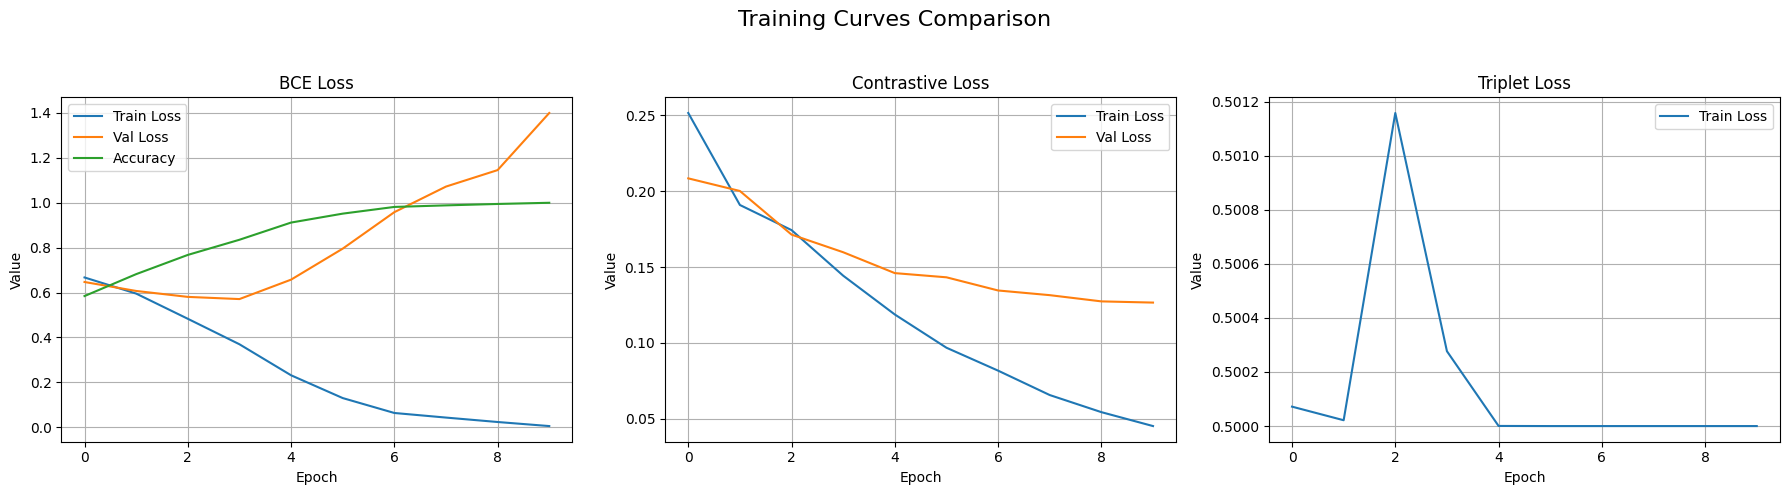

In [10]:
def plot_all_trainings(histories, titles):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, history, title in zip(axes, histories, titles):
        ax.plot(history.history['loss'], label='Train Loss')
        if 'val_loss' in history.history:
            ax.plot(history.history['val_loss'], label='Val Loss')
        if 'accuracy' in history.history:
            ax.plot(history.history['accuracy'], label='Accuracy')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Value')
        ax.grid(True)
        ax.legend()

    plt.suptitle("Training Curves Comparison", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# 📈 Call it with your training histories
plot_all_trainings(
    [history_bce, history_contrast, history_triplet],
    ['BCE Loss', 'Contrastive Loss', 'Triplet Loss']
)


In [11]:
import matplotlib.pyplot as plt

def show_pair_prediction(model, x1, x2, true_label, loss_type='bce'):
    pred = model.predict([np.expand_dims(x1, axis=0), np.expand_dims(x2, axis=0)])

    if loss_type == 'bce':
        pred_score = pred[0][0]
        pred_label = 1 if pred_score > 0.5 else 0
        title = f"Prediction: {pred_label} ({pred_score:.2f}) | True: {true_label}"
    elif loss_type == 'contrastive':
        distance = pred[0][0]
        threshold = 0.5  # you can tune this
        pred_label = 1 if distance < threshold else 0
        title = f"Distance: {distance:.2f} | Pred: {pred_label} | True: {true_label}"

    # Display side by side
    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plt.imshow(x1.squeeze(), cmap='gray')
    plt.title("Image 1")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(x2.squeeze(), cmap='gray')
    plt.title("Image 2")
    plt.axis('off')

    plt.suptitle(title)
    plt.show()


🔹 BCE Model
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


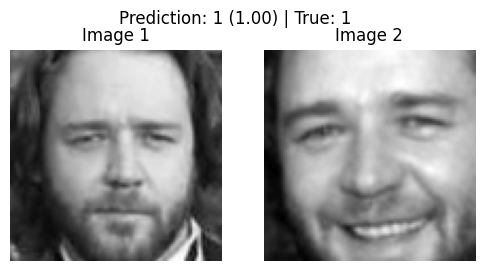

🔹 Contrastive Model
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


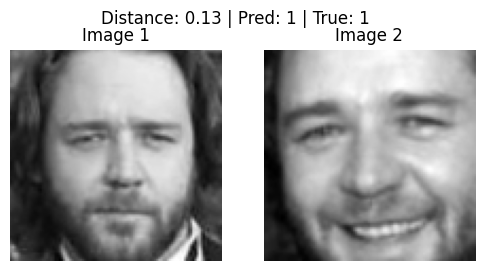

🔹 Triplet Model


ValueError: Layer "functional_5" expects 3 input(s), but it received 2 input tensors. Inputs received: [<tf.Tensor 'data:0' shape=(1, 100, 100, 1) dtype=float32>, <tf.Tensor 'data_1:0' shape=(1, 100, 100, 1) dtype=float32>]

In [12]:
idx = 10
sample_x1 = X1_test[idx]
sample_x2 = X2_test[idx]
sample_y = y_test[idx]

print("🔹 BCE Model")
show_pair_prediction(bce_model, sample_x1, sample_x2, sample_y, loss_type='bce')

print("🔹 Contrastive Model")
show_pair_prediction(contrast_model, sample_x1, sample_x2, sample_y, loss_type='contrastive')
print("🔹 Triplet Model")
show_pair_prediction(triplet_model, sample_x1, sample_x2, sample_y, loss_type='contrastive')
